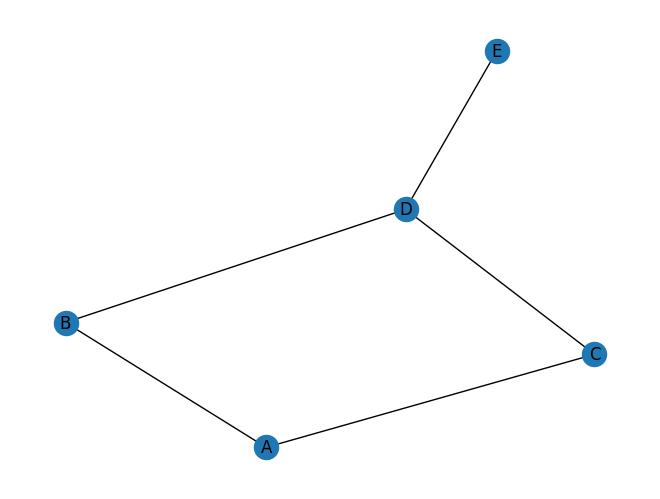

In [ ]:
# Step 1: Import required libraries
import networkx as nx
import matplotlib.pyplot as plt
# Step 2: Create a graph
G=nx.Graph()
# Step 3: Add nodes representing users
G.add_nodes_from(['A', 'B', 'C', 'D', 'E'])
# Step 4: Add edges representing interactions
G.add_edge('A', 'B')
G.add_edge('A', 'C')
G.add_edge('B', 'D')
G.add_edge('C', 'D')
G.add_edge('D', 'E')
# Step 5: Compute centrality measures
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G)
# Step 6: Visualize the network
nx.draw(G, with_labels=True)
plt.show()

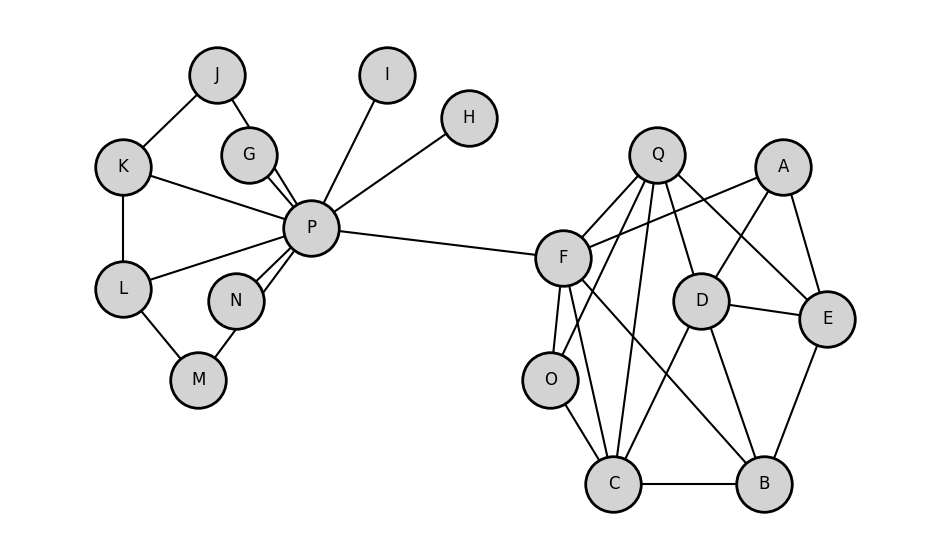

--- 1. DEGREE OF EACH NODE ---
Node: P | Degree: 9
Node: J | Degree: 2
Node: G | Degree: 1
Node: K | Degree: 3
Node: L | Degree: 3
Node: N | Degree: 1
Node: M | Degree: 2
Node: I | Degree: 1
Node: H | Degree: 1
Node: F | Degree: 6
Node: Q | Degree: 5
Node: O | Degree: 3
Node: C | Degree: 5
Node: A | Degree: 3
Node: B | Degree: 4
Node: D | Degree: 5
Node: E | Degree: 4

--- 2. DEGREE CENTRALITY ---
Node: P | Score: 0.562
Node: F | Score: 0.375
Node: Q | Score: 0.312
Node: C | Score: 0.312
Node: D | Score: 0.312
Node: B | Score: 0.250
Node: E | Score: 0.250
Node: K | Score: 0.188
Node: L | Score: 0.188
Node: O | Score: 0.188
Node: A | Score: 0.188
Node: J | Score: 0.125
Node: M | Score: 0.125
Node: G | Score: 0.062
Node: N | Score: 0.062
Node: I | Score: 0.062
Node: H | Score: 0.062

--- 3. BETWEENNESS CENTRALITY ---
Node: P | Score: 0.733
Node: F | Score: 0.549
Node: Q | Score: 0.064
Node: B | Score: 0.051
Node: A | Score: 0.049
Node: C | Score: 0.031
Node: D | Score: 0.015
Node: E | Sc

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# --- 1. SETUP GRAPH ---
G = nx.Graph()

# Left Cluster (Hub P)
left_spokes = ['J', 'G', 'K', 'L', 'N', 'M', 'I', 'H']
for node in left_spokes:
    G.add_edge('P', node)

G.add_edge('J', 'K')
G.add_edge('K', 'L')
G.add_edge('L', 'M')

# Bridge
G.add_edge('P', 'F')

# Right Cluster (Dense Group)
G.add_edges_from([
    ('F', 'Q'), ('F', 'O'), ('F', 'C'), ('F', 'A'), ('F', 'B')
])

G.add_edges_from([
    ('Q', 'O'), ('Q', 'C'), ('Q', 'D'), ('Q', 'E')
])

G.add_edge('O', 'C')

G.add_edges_from([
    ('C', 'D'), ('C', 'B')
])

G.add_edges_from([
    ('D', 'A'), ('D', 'E'), ('D', 'B')
])

G.add_edge('A', 'E')
G.add_edge('E', 'B')

# --- 2. NODE POSITIONS FOR GRAPH ---
pos = {
    'P': (4.0, 5.0),
    'I': (5.2, 7.5),
    'H': (6.5, 6.8),
    'J': (2.5, 7.5),
    'G': (3.0, 6.2),
    'K': (1.0, 6.0),
    'L': (1.0, 4.0),
    'N': (2.8, 3.8),
    'M': (2.2, 2.5),
    'F': (8.0, 4.5),
    'O': (7.8, 2.5),
    'Q': (9.5, 6.2),
    'C': (8.8, 0.8),
    'D': (10.2, 3.8),
    'A': (11.5, 6.0),
    'E': (12.2, 3.5),
    'B': (11.2, 0.8)
}

# --- 3. DRAW GRAPH ---
plt.figure(figsize=(12, 7))

nx.draw_networkx_nodes(
    G, pos,
    node_size=1600,
    node_color='lightgray',
    edgecolors='black',
    linewidths=2
)

nx.draw_networkx_edges(
    G, pos,
    width=1.5,
    edge_color='black'
)

nx.draw_networkx_labels(
    G, pos,
    font_size=12,
    font_color='black',
    font_family='sans-serif'
)

plt.axis('off')
plt.margins(0.1)
plt.show()

# --- 4. PERFORM ANALYSIS ---

print("--- 1. DEGREE OF EACH NODE ---")
degree = dict(G.degree())
for node, d in degree.items():
    print(f"Node: {node} | Degree: {d}")

print("\n--- 2. DEGREE CENTRALITY ---")
deg_centrality = nx.degree_centrality(G)

# Sort highest first
sorted_degree = sorted(deg_centrality.items(), key=lambda x: x[1], reverse=True)

for node, score in sorted_degree:
    print(f"Node: {node} | Score: {score:.3f}")

print("\n--- 3. BETWEENNESS CENTRALITY ---")
bet_centrality = nx.betweenness_centrality(G)
sorted_bet = sorted(bet_centrality.items(), key=lambda x: x[1], reverse=True)

for node, score in sorted_bet:
    print(f"Node: {node} | Score: {score:.3f}")

print("\n--- 4. TOP 3 INFLUENTIAL USERS ---")

print("Top 3 by Popularity (Degree):")
for i, (node, score) in enumerate(sorted_degree[:3], 1):
    print(f" #{i}: {node} (Score: {score:.3f})")

print("\nTop 3 by Control (Betweenness):")
for i, (node, score) in enumerate(sorted_bet[:3], 1):
    print(f" #{i}: {node} (Score: {score:.3f})")

print("\n--- 5. CLIQUES IN THE NETWORK ---")
cliques = list(nx.find_cliques(G))

for i, clique in enumerate(cliques, 1):
    print(f"Clique {i}: {clique}")


NETFLIX CENTRALITY VALUES
    Degree  Eigenvector  Betweenness  Closeness
N1     0.4       0.3251          0.0     0.5556
N2     0.6       0.4440          0.2     0.7143
N3     0.6       0.4440          0.2     0.7143
N4     0.6       0.4440          0.2     0.7143
N5     0.6       0.4440          0.2     0.7143
N6     0.4       0.3251          0.0     0.5556

Top 3 Influential Users:
    Degree  Eigenvector  Betweenness  Closeness
N2     0.6     0.444037          0.2   0.714286
N3     0.6     0.444037          0.2   0.714286
N5     0.6     0.444037          0.2   0.714286


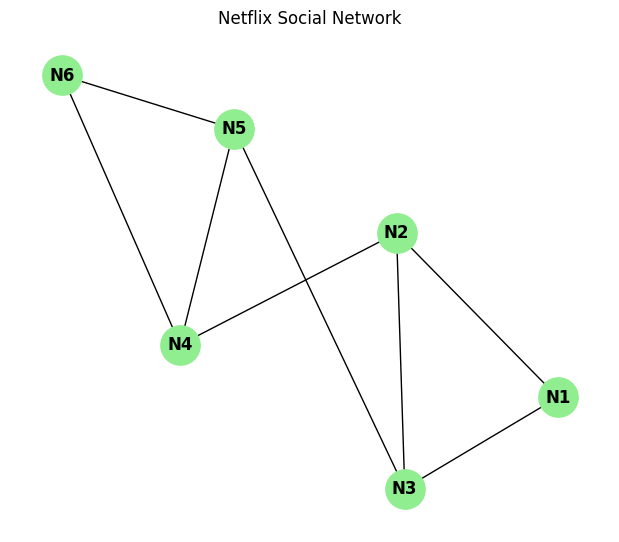


JIOHOTSTAR CENTRALITY VALUES
    Degree  Eigenvector  Betweenness  Closeness
J1     0.6       0.4786         0.10     0.7143
J2     0.6       0.4545         0.15     0.7143
J3     0.6       0.4545         0.15     0.7143
J4     0.4       0.3128         0.05     0.6250
J5     0.6       0.4028         0.20     0.7143
J6     0.4       0.3128         0.05     0.6250

Top 3 Influential Users:
    Degree  Eigenvector  Betweenness  Closeness
J1     0.6     0.478557         0.10   0.714286
J2     0.6     0.454491         0.15   0.714286
J3     0.6     0.454491         0.15   0.714286


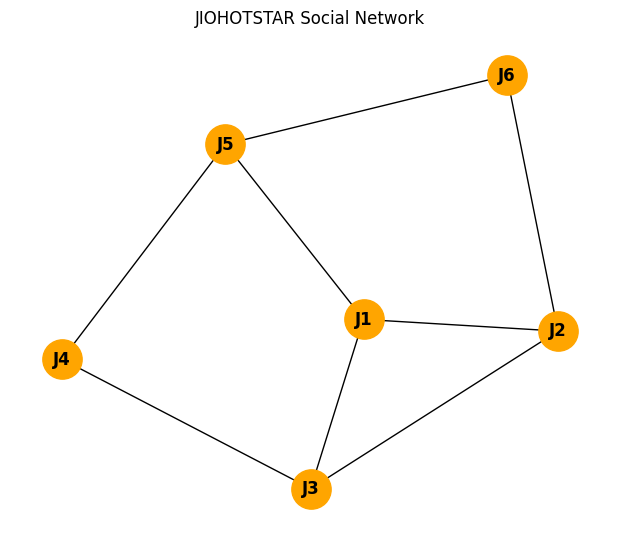


COMBINED CENTRALITY VALUES
    Degree  Eigenvector  Betweenness  Closeness
N1  0.1538       0.2139       0.0000     0.3333
N2  0.3077       0.3451       0.2628     0.4333
N3  0.2308       0.2971       0.0620     0.3824
N4  0.2308       0.2955       0.0684     0.3824
N5  0.3077       0.3327       0.2244     0.4194
N6  0.1538       0.2093       0.0000     0.3250
J1  0.2308       0.2799       0.0299     0.3611
J2  0.2308       0.2627       0.0705     0.3611
J3  0.3077       0.3431       0.3376     0.4643
J4  0.2308       0.2579       0.2543     0.4483
J5  0.2308       0.2343       0.0940     0.3611
J6  0.1538       0.1656       0.0064     0.3095
B1  0.1538       0.2292       0.2500     0.4483
B2  0.1538       0.1968       0.2115     0.4333

Top 3 Influential Users:
      Degree  Eigenvector  Betweenness  Closeness
N2  0.307692     0.345050     0.262821   0.433333
J3  0.307692     0.343055     0.337607   0.464286
N5  0.307692     0.332683     0.224359   0.419355


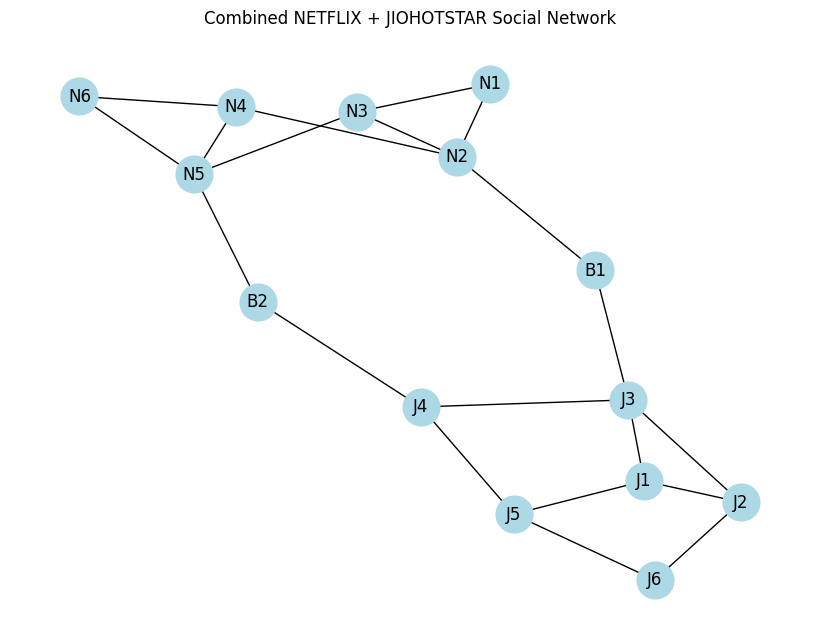

In [ ]:
# Install libraries (run once in notebook)
!pip install networkx pandas matplotlib

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# FUNCTION TO CALCULATE 4 CENTRALITIES
# -----------------------------
def calculate_centralities(G, title):

    degree = nx.degree_centrality(G)
    eigen = nx.eigenvector_centrality(G, max_iter=1000)
    between = nx.betweenness_centrality(G)
    close = nx.closeness_centrality(G)

    df = pd.DataFrame({
        "Degree": degree,
        "Eigenvector": eigen,
        "Betweenness": between,
        "Closeness": close
    })

    print("\n==============================")
    print(f"{title} CENTRALITY VALUES")
    print("==============================")
    print(df.round(4))

    print("\nTop 3 Influential Users:")
    print(df.sort_values("Eigenvector", ascending=False).head(3))

    return df


# -----------------------------
# 1. NETFLIX NETWORK
# -----------------------------
G_netflix = nx.Graph()

netflix_users = ['N1','N2','N3','N4','N5','N6']

netflix_edges = [
    ('N1','N2'), ('N1','N3'), ('N2','N3'),
    ('N2','N4'), ('N3','N5'),
    ('N4','N5'), ('N5','N6'),
    ('N4','N6')
]

G_netflix.add_nodes_from(netflix_users)
G_netflix.add_edges_from(netflix_edges)

df_netflix = calculate_centralities(G_netflix, "NETFLIX")


# -----------------------------
# NETFLIX NETWORK VISUALIZATION
# -----------------------------
plt.figure(figsize=(6,5))

pos_netflix = nx.spring_layout(G_netflix, seed=42)

nx.draw(
    G_netflix,
    pos_netflix,
    with_labels=True,
    node_color="lightgreen",
    node_size=800,
    font_weight='bold'
)

plt.title("Netflix Social Network")
plt.show()


# -----------------------------
# 2. JIOHOTSTAR NETWORK
# -----------------------------
G_jiohotstar = nx.Graph()

jiohotstar_users = ['J1','J2','J3','J4','J5','J6']

jiohotstar_edges = [
    ('J1','J2'), ('J1','J3'), ('J2','J3'),
    ('J3','J4'), ('J4','J5'),
    ('J5','J6'), ('J2','J6'),
    ('J1','J5')
]

G_jiohotstar.add_nodes_from(jiohotstar_users)
G_jiohotstar.add_edges_from(jiohotstar_edges)

df_jiohotstar = calculate_centralities(G_jiohotstar, "JIOHOTSTAR")


# -----------------------------
# JIOHOTSTAR NETWORK VISUALIZATION
# -----------------------------
plt.figure(figsize=(6,5))

pos_jiohotstar = nx.spring_layout(G_jiohotstar, seed=42)

nx.draw(
    G_jiohotstar,
    pos_jiohotstar,
    with_labels=True,
    node_color="orange",
    node_size=800,
    font_weight='bold'
)

plt.title("JIOHOTSTAR Social Network")
plt.show()


# -----------------------------
# 3. COMBINED NETWORK
# -----------------------------
G_combined = nx.Graph()

bridge_users = ['B1','B2']

G_combined.add_nodes_from(netflix_users + jiohotstar_users + bridge_users)

G_combined.add_edges_from(netflix_edges + jiohotstar_edges)

bridge_edges = [
    ('B1','N2'), ('B1','J3'),
    ('B2','N5'), ('B2','J4')
]

G_combined.add_edges_from(bridge_edges)

df_combined = calculate_centralities(G_combined, "COMBINED")


# -----------------------------
# COMBINED NETWORK VISUALIZATION
# -----------------------------
plt.figure(figsize=(8,6))

pos = nx.spring_layout(G_combined, seed=42)

nx.draw(
    G_combined,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=700
)

plt.title("Combined NETFLIX + JIOHOTSTAR Social Network")
plt.show()